#Data Integeration<br>
“Data Integration” is the part of your Courier Management System mini project, it means combining data from different sources/modules into one system.

#methods of data integration<br>
1.Manual integration.<br>
   Manual data integration is the process of combining data from multiple sources by hand rather than through automated tools or pipelines<br>

2.Application programming interface(API) integration.<br>
   API integration is the method of connecting two or more software systems through their application programming interfaces — the defined sets of rules that let them request and exchange data with each other. Rather than moving large batches of data or manually copying records, API integration lets systems talk to each other in real time, on demand<br>

3.ETL(extract,transform,load) integration.<br>
   ETL (Extract, Transform, Load) is a batch method for moving data from sources into a target system, usually a data warehouse.

  Extract — pull raw data from source systems<br>
  Transform — clean, standardize, deduplicate, and reshape it<br>
  Load — write the clean data into the warehouse.<br>

4.Virtual integration<br>
   Virtual integration is an approach where data from multiple sources is combined into a unified view without physically moving or copying the data. Instead of consolidating data into a central warehouse, it provides access to the data where it already lives, presenting it as if it were one system.


# data concatination

In [ ]:
import pandas as pd

df1 = pd.DataFrame({
    "acc":[1,2,3],
    "name":["ram","hari","shyam"],
    "age":[2,3,4]
})

In [ ]:
df1

,acc,name,age
0,1,ram,2
1,2,hari,3
2,3,shyam,4


In [ ]:
df2 = pd.DataFrame({
    "acc":[5,6,7],
    "loan":[44,55,66]
})

In [ ]:
df2

,acc,loan
0,5,44
1,6,55
2,7,66


In [ ]:
row_concat = pd.concat([df1,df2],axis = 0)
row_concat

,acc,name,age,loan
0,1,ram,2.0,NaN
1,2,hari,3.0,NaN
2,3,shyam,4.0,NaN
0,5,NaN,NaN,44.0
1,6,NaN,NaN,55.0
2,7,NaN,NaN,66.0


In [ ]:
column_concat = pd.concat([df1,df2],axis = 1)
column_concat

,acc,name,age,acc,loan
0,1,ram,2,5,44
1,2,hari,3,6,55
2,3,shyam,4,7,66


#merge
merging is the process of combining two or more dataframes based on common columns.

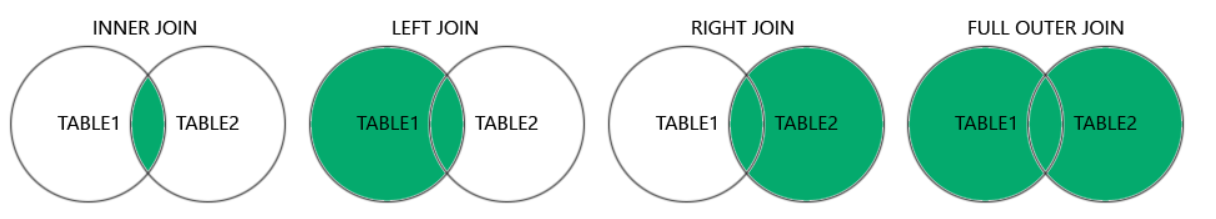

In [ ]:
students = pd.DataFrame({
    "ID":[1,2,3],
    "Name":["ram","hari","shyam"]
})

In [ ]:
marks = pd.DataFrame({
    "ID":[1,4,5],
    "marks":[84,95,66]
})

In [ ]:
pd.merge(students,marks,how = "outer")

,ID,Name,marks
0,1,ram,84.0
1,2,hari,NaN
2,3,shyam,NaN
3,4,NaN,95.0
4,5,NaN,66.0


In [ ]:
pd.merge(students,marks,how = "left")

,ID,Name,marks
0,1,ram,84.0
1,2,hari,NaN
2,3,shyam,NaN


In [ ]:
pd.merge(students,marks,how = "right")

,ID,Name,marks
0,1,ram,84
1,4,NaN,95
2,5,NaN,66


In [ ]:
pd.merge(students,marks,how = "inner")

,ID,Name,marks
0,1,ram,84


In [ ]:
result = pd.merge(students,marks,on = "ID")
result

,ID,Name,marks
0,1,ram,84


# join in pandas<br>


In [ ]:
df1 = pd.DataFrame({
    "key":["E","B","C","Z"],
    "inc_val":[99,66,33,22],
    "acc":[1,2,5,7]
})
df1

,key,inc_val,acc
0,E,99,1
1,B,66,2
2,C,33,5
3,Z,22,7


In [ ]:
df1 = df1.set_index("key")
df1

,inc_val,acc
key,,
E,99,1
B,66,2
C,33,5
Z,22,7


In [ ]:
df2 = pd.DataFrame({
    "key":["A","B","C","D"],
    "inc_val":[55,66,31,12],
    "acc":[1,2,5,7]
})

In [ ]:
df2 = df2.set_index("key")
df2

,inc_val,acc
key,,
A,55,1
B,66,2
C,31,5
D,12,7


In [ ]:
df1.join(df2,how = "inner",lsuffix="_x")

,inc_val_x,acc_x,inc_val,acc
key,,,,
B,66,2,66,2
C,33,5,31,5


In [ ]:
df1.join(df2,how = "outer",lsuffix="_x")

,inc_val_x,acc_x,inc_val,acc
key,,,,
A,NaN,NaN,55.0,1.0
B,66.0,2.0,66.0,2.0
C,33.0,5.0,31.0,5.0
D,NaN,NaN,12.0,7.0
E,99.0,1.0,NaN,NaN
Z,22.0,7.0,NaN,NaN


In [ ]:
df2.join(df1,how = "right",lsuffix="_2")

,inc_val_2,acc_2,inc_val,acc
key,,,,
E,NaN,NaN,99,1
B,66.0,2.0,66,2
C,31.0,5.0,33,5
Z,NaN,NaN,22,7


In [ ]:
df2.join(df1,how = "left",lsuffix="_2")

,inc_val_2,acc_2,inc_val,acc
key,,,,
A,55,1,NaN,NaN
B,66,2,66.0,2.0
C,31,5,33.0,5.0
D,12,7,NaN,NaN


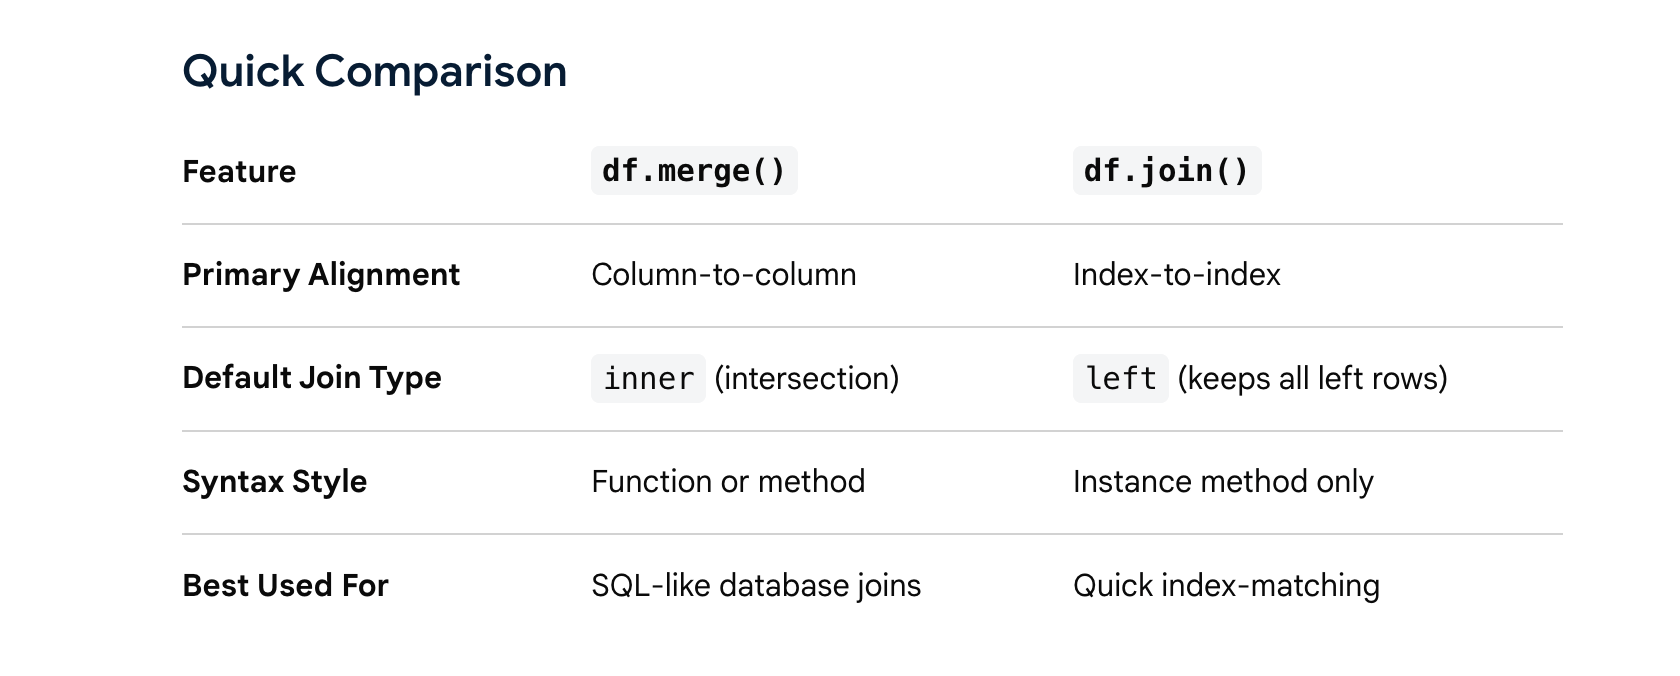

#stacking<br>
stacking refers to two related but distinct concepts — and the term can mean slightly different things depending on context.

In [ ]:
df2 = pd.DataFrame(
    {
    "key":["A","B","C","D"],
    "inc_val":[55,66,31,12],
    "acc":[1,2,5,7]
    },index=["X","Y","Z","W"]
)
df2

,key,inc_val,acc
X,A,55,1
Y,B,66,2
Z,C,31,5
W,D,12,7


In [ ]:
# stack = move columns into row
#
stacked = df2.stack()
stacked

X  key         A
   inc_val    55
   acc         1
Y  key         B
   inc_val    66
   acc         2
Z  key         C
   inc_val    31
   acc         5
W  key         D
   inc_val    12
   acc         7
dtype: object

In [ ]:
#concat,merge,join,stack => Data integration

#Real-world example<br>

Imagine an e-commerce company.

january sales + February sales -> concat()

Customers + Orders using Customer_id -> merge()



#Encoding<br>
1.label encoding<br>
2.one hot encoding<br>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
titanic_df = pd.read_csv('/content/drive/MyDrive/data file/titanic-data.csv')

In [ ]:
titanic_df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [ ]:
pd.get_dummies(titanic_df,columns = ["Sex"],dtype=int)

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_female,Sex_male
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,S,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,C,1,0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,S,1,0
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,S,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",27.0,0,0,211536,13.0000,NaN,S,0,1
887,888,1,1,"Graham, Miss. Margaret Edith",19.0,0,0,112053,30.0000,B42,S,1,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",NaN,1,2,W./C. 6607,23.4500,NaN,S,1,0
889,890,1,1,"Behr, Mr. Karl Howell",26.0,0,0,111369,30.0000,C148,C,0,1


In [ ]:
pd.get_dummies(titanic_df,columns=["Embarked"],dtype=int)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,0,0,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,0,0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,0,0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,0,0,1
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,1,0,0
